In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv('/content/Poverty and Employement in Seattle_Cleaned_data_python.csv')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 48 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Neighborhood Name                                                                               92 non-null     object 
 1   Neighborhood Type                                                                               92 non-null     object 
 2   Neighborhood Subtype                                                                            92 non-null     object 
 3    Population 16 years and over                                                                   92 non-null     int64  
 4    Population 16 years and over not in labor force                                                92 non-null     int64  
 5    Population 16 ye

In [ ]:
df.head()

,Neighborhood Name,Neighborhood Type,Neighborhood Subtype,Population 16 years and over,Population 16 years and over not in labor force,Population 16 years and over in civilian labor force,Population 16 years and over in civilian labor force unemployed,Population for whom poverty status is determined,People with Income to Poverty Ratio Under .50,People with Income to Poverty .50 to .99,...,Family with related children below poverty,Family without related children below poverty,Single parents with related children below poverty,Other families below poverty,Unemployment_rate_16+,Employment_rate_16+,Laborforce_participation_16+,NILF_share_16+,Key,ACS Vinatage
0,Olympic Hills/Victory Heights,CRA,North,14516,3751,10745,574,17039,670,717,...,0.00,0.01,0.02,0.02,0.05,0.70,0.74,0.26,Olympic Hills/Victory Heights | North,5Y23
1,Cedar Park/Meadowbrook,CRA,North,12513,3677,8836,259,14445,498,824,...,0.02,0.01,0.01,0.01,0.03,0.69,0.71,0.29,Cedar Park/Meadowbrook | North,5Y23
2,Broadview/Bitter Lake,CRA,Northwest,13260,4753,8507,356,15645,676,1105,...,0.00,0.01,0.05,0.01,0.04,0.61,0.64,0.36,Broadview/Bitter Lake | Northwest,5Y23
3,Licton Springs,CRA,Northwest,8798,1895,6903,267,9597,631,429,...,0.00,0.01,0.01,0.04,0.04,0.75,0.78,0.22,Licton Springs | Northwest,5Y23
4,Greenwood/Phinney Ridge,CRA,Northwest,23396,4985,18381,565,26912,854,371,...,0.01,0.00,0.01,0.00,0.03,0.76,0.79,0.21,Greenwood/Phinney Ridge | Northwest,5Y23


In [ ]:
df.isnull().sum()


,0
Neighborhood Name,0
Neighborhood Type,0
Neighborhood Subtype,0
Population 16 years and over,0
Population 16 years and over not in labor force,0
Population 16 years and over in civilian labor force,0
Population 16 years and over in civilian labor force unemployed,0
Population for whom poverty status is determined,0
People with Income to Poverty Ratio Under .50,0
People with Income to Poverty .50 to .99,0


## **Insight from above line of code:**
All columns value turned out to be 0 meaning there are no missing values in my data. and it is handled properly.


In [ ]:
df.describe()

,Population 16 years and over,Population 16 years and over not in labor force,Population 16 years and over in civilian labor force,Population 16 years and over in civilian labor force unemployed,Population for whom poverty status is determined,People with Income to Poverty Ratio Under .50,People with Income to Poverty .50 to .99,People with Income to Poverty 1.00 to 1.24,People with Income to Poverty 1.25 to 1.49,People with Income to Poverty 1.50 to 1.84,...,Employment_rate_20_64,Nilf_share_20_64,Family with related children below poverty,Family without related children below poverty,Single parents with related children below poverty,Other families below poverty,Unemployment_rate_16+,Employment_rate_16+,Laborforce_participation_16+,NILF_share_16+
count,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,...,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000
mean,21161.771739,5483.706522,15641.054348,662.250000,23576.413043,1266.586957,1061.413043,513.717391,454.597826,632.119565,...,0.823043,0.138370,0.008478,0.015435,0.025543,0.011304,0.043478,0.709891,0.741739,0.255217
std,40891.954562,11048.409599,29932.155811,1175.229841,47488.824808,2142.054006,1707.860201,878.497673,767.219212,1215.274616,...,0.051328,0.048182,0.013582,0.032494,0.029958,0.016982,0.020079,0.073327,0.070346,0.070469
min,469.000000,102.000000,367.000000,0.000000,497.000000,6.000000,15.000000,0.000000,0.000000,21.000000,...,0.640000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.550000,0.120000
25%,5919.750000,1483.000000,4156.750000,160.000000,6487.250000,284.000000,258.500000,97.500000,114.000000,152.000000,...,0.800000,0.110000,0.000000,0.000000,0.007500,0.000000,0.030000,0.660000,0.690000,0.200000
50%,10291.000000,2478.000000,7274.000000,280.500000,11507.000000,523.000000,523.500000,225.500000,238.000000,272.500000,...,0.830000,0.130000,0.000000,0.010000,0.020000,0.000000,0.040000,0.715000,0.740000,0.255000
75%,16542.250000,4346.000000,12487.500000,558.000000,17400.250000,1123.250000,1053.000000,535.000000,397.000000,634.250000,...,0.852500,0.160000,0.010000,0.020000,0.030000,0.020000,0.050000,0.770000,0.800000,0.300000
max,340150.000000,92665.000000,247082.000000,9084.000000,402638.000000,14775.000000,11738.000000,5933.000000,5735.000000,9839.000000,...,0.940000,0.330000,0.060000,0.280000,0.150000,0.070000,0.150000,0.850000,0.880000,0.450000


## **Few Insights from Descriptive statistics:**
**1.Poverty_rate_20_64 (Column 32):**

-Mean is 0.120, meaning for 20_64 age group people accross neighborhoods ahve a poverty rate of 12%

-Min is 0.03, meaning lowest poverty is 3%

**2.Unemployment_rate_20_64 (Column 33):**

-Mean is 0.04, meaning average unemployment rate for 20_64 age group is about 4%

-Max is 0.15, meaning highest unemployment rate is 15%

**3.Laborforce_participation_20_64 (Column 34):**

-Mean is 0.823, meaning about 82.3% on average are in laborfore(either working or seeking employment)

-Max is 0.94, meaning 94% is the highest percent of labor force participation is some neighborhood.

In [ ]:
print('Seattle neighborhood Comparission:')
print('We are comparing based on neighborhood subtypes')
print()
print('All available Seattle neighborhood subtypes are:')
subtypes = df['Neighborhood Subtype'].unique()
subtypes = sorted(subtypes)
print()

for i, subtype in enumerate(subtypes,1):
  print(f'{i}.{subtype}')


try:
  choice = int(input("Enter the number of subtype that u wanted to see: "))
  print()
  selected_subtype = subtypes[choice-1]
except:
  print('Invalid input, please enter a valid number from the list.')
  exit()

subtype_data = df[df['Neighborhood Subtype'] == selected_subtype]

for i, row in subtype_data.iterrows():
    name_of_neighborhood = row['Neighborhood Name']
    poverty_of_neighborhood = row['Poverty_rate_20_64']
    unemployment_of_neighborhood = row['Unemployment_rate_20_64']
    employment = row['Employment_rate_20_64']
    laborforce = row['Laborforce_participation_20_64']

    print(f'{name_of_neighborhood}')
    print(f'Poverty Rate: {poverty_of_neighborhood:.1%}')
    print(f'Unemployment: {unemployment_of_neighborhood:.1%}')
    print(f'Employment Rate: {employment:.1%}')
    print(f'Laborforce Participation: {laborforce:.1%}')
    print()

minimum_poverty = subtype_data['Poverty_rate_20_64'].min()
maximum_poverty = subtype_data['Poverty_rate_20_64'].max()
minimum_employment = subtype_data['Employment_rate_20_64'].min()
maximum_employment = subtype_data['Employment_rate_20_64'].max()

print("-" * 50)
print()
print("Key metrics from my data:")
print()
print(f"Lowest Poverty Rate of neighborhood is: {minimum_poverty:.1%}")
print(f"Highest Poverty Rate of nighborhood is: {maximum_poverty:.1%}")
print(f"Lowest Employment Rate of neighborhood is: {minimum_employment:.1%}")
print(f"Highest Employment Rate of neighborhood is: {maximum_employment:.1%}")

Seattle neighborhood Comparission:
We are comparing based on neighborhood subtypes

All available Seattle neighborhood subtypes are:

1.Ballard
2.Central
3.Delridge Neighborhoods
4.Downtown
5.East
6.Greater Duwamish
7.Hub Urban Village
8.Lake Union
9.Magnolia/Queen Anne
10.Manufacturing Industrial
11.North
12.Northeast
13.Northwest
14.Outside Villages
15.Residential Urban Village
16.Southeast
17.Southwest
18.Unknown
19.Urban Center
Enter the number of subtype that u wanted to see: 4

Belltown
Poverty Rate: 11.0%
Unemployment: 3.0%
Employment Rate: 84.0%
Laborforce Participation: 86.0%

Downtown Commercial Core
Poverty Rate: 15.0%
Unemployment: 3.0%
Employment Rate: 73.0%
Laborforce Participation: 76.0%

Pioneer Square/International District
Poverty Rate: 25.0%
Unemployment: 7.0%
Employment Rate: 71.0%
Laborforce Participation: 76.0%

--------------------------------------------------

Key metrics from my data:

Lowest Poverty Rate of neighborhood is: 11.0%
Highest Poverty Rate of nighb

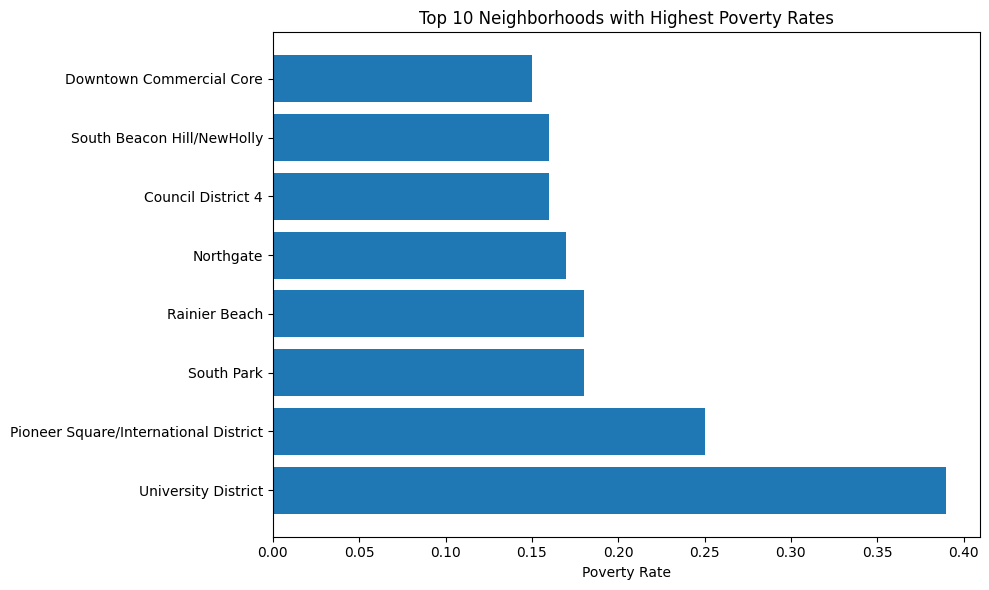

In [ ]:
plt.figure(figsize=(10, 6))
top_poverty = df.nlargest(10, 'Poverty_rate_20_64')[['Neighborhood Name', 'Poverty_rate_20_64']]
plt.barh(top_poverty['Neighborhood Name'], top_poverty['Poverty_rate_20_64'])
plt.xlabel('Poverty Rate')
plt.title('Top 10 Neighborhoods with Highest Poverty Rates')
plt.tight_layout()
plt.show()

## **Insights:**
###  Top 10 Highest poverty neighborhoods
- From the above graph University District has highest poverty of 39%, can be probably due to more student population.
- Pioneer Square/International District and South Park are the next highest at  around 25%



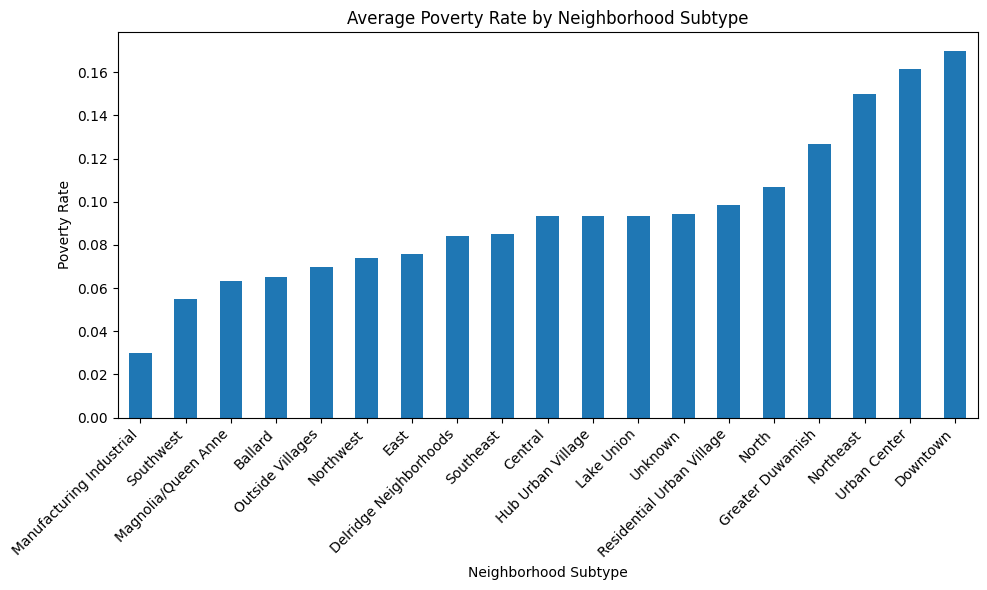

In [ ]:
plt.figure(figsize=(10, 6))
df.groupby('Neighborhood Subtype')['Poverty_rate_20_64'].mean().sort_values().plot(kind='bar')
plt.title('Average Poverty Rate by Neighborhood Subtype')
plt.ylabel('Poverty Rate')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

## **Insights:**
### POVERTY RATE BY SUBTYPE
- University/Urban Center areas have highest poverty - again can be because of their student population.
- Manufacturing Industrial neighborhood has lowest poverty, whereas Residential and Hub Urban Villages have shown moderate poverty rates

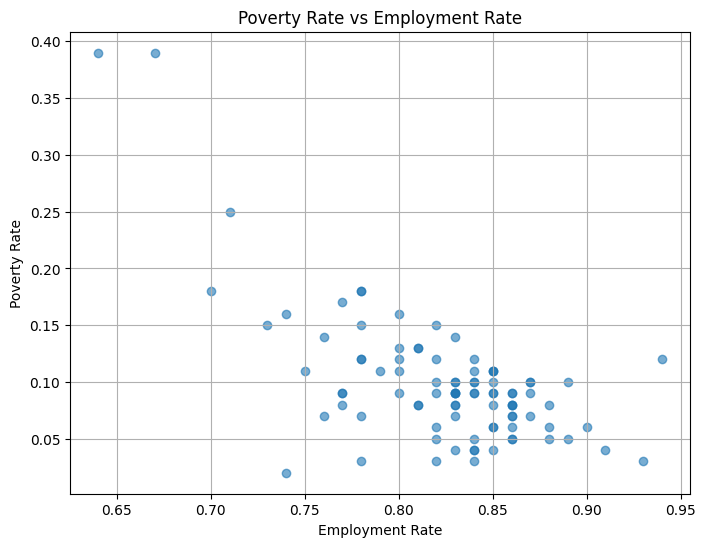

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Employment_rate_20_64'], df['Poverty_rate_20_64'], alpha=0.6)
plt.xlabel('Employment Rate')
plt.ylabel('Poverty Rate')
plt.title('Poverty Rate vs Employment Rate')
plt.grid(True)
plt.show()

## **Insights:**
### POVERTY VS EMPLOYMENT SCATTER PLOT
- A clear negative relationship, meaning higher employement neighborhoods have lower poverty.
- Some outliers do exixst, meaning employment is high and poverty is also high.

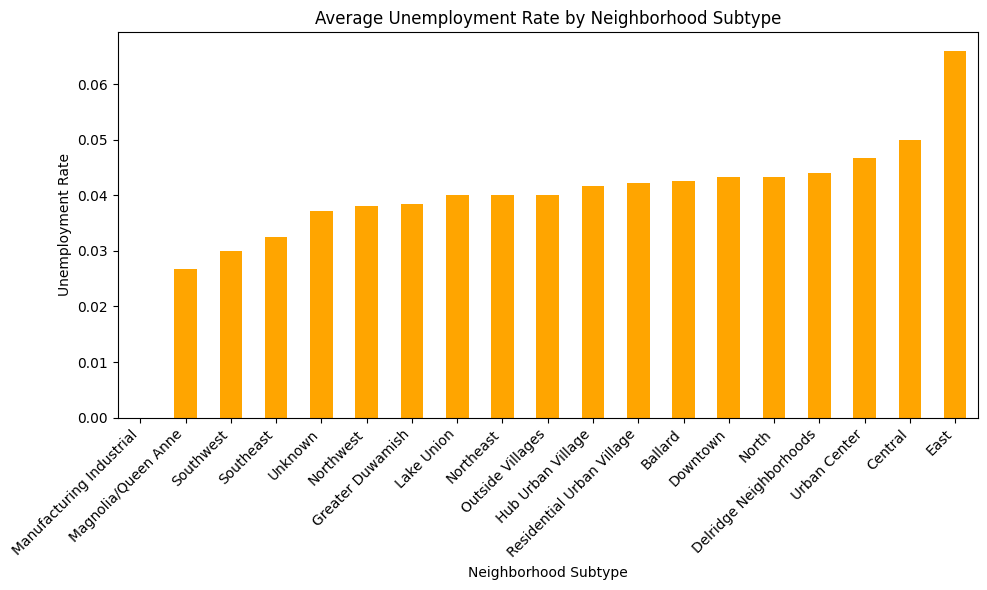

In [ ]:
plt.figure(figsize=(10, 6))
df.groupby('Neighborhood Subtype')['Unemployment_rate_20_64'].mean().sort_values().plot(kind='bar', color='orange')
plt.title('Average Unemployment Rate by Neighborhood Subtype')
plt.ylabel('Unemployment Rate')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

## **Insights:**
### UNEMPLOYMENT BY SUBTYPE
- Unemployment rate are relatively low across all the subtypes with mostly under 5%
- Manufacturing Industrial subtype has nearly 0 unemployment.


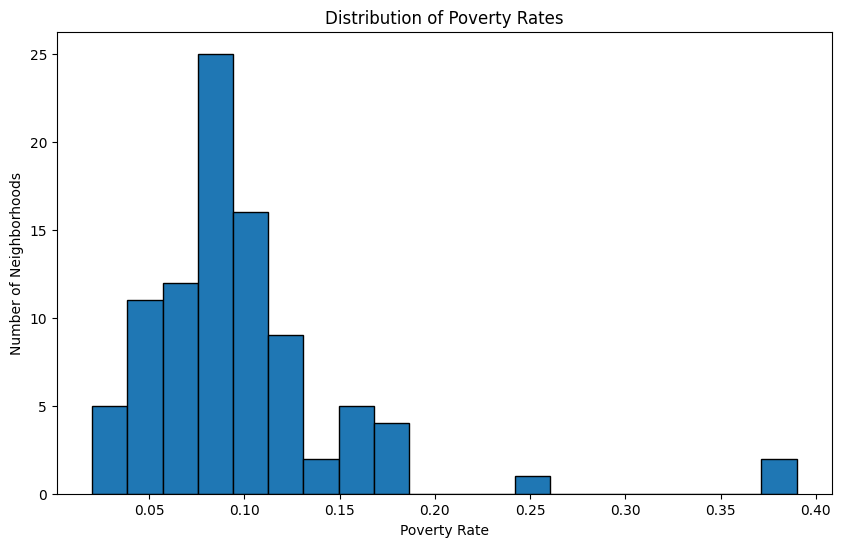

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['Poverty_rate_20_64'], bins=20, edgecolor='black')
plt.xlabel('Poverty Rate')
plt.ylabel('Number of Neighborhoods')
plt.title('Distribution of Poverty Rates')
plt.show()


## **Insights:**
### POVERTY DISTRIBUTION HISTOGRAM
- Most neighborhoods have poverty between 5 to 15%
- Very few neighborhoods have extreme poverty of more than 25%.

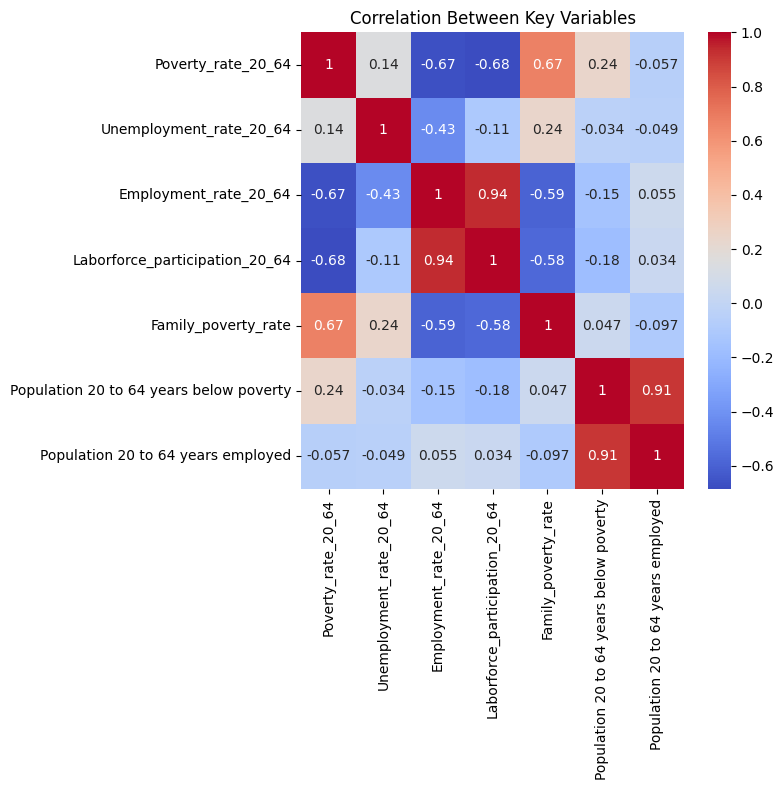

In [ ]:
correlation_variables = [
    'Poverty_rate_20_64',
    'Unemployment_rate_20_64',
    'Employment_rate_20_64',
    'Laborforce_participation_20_64',
    'Family_poverty_rate',
    'Population 20 to 64 years below poverty',
    'Population 20 to 64 years employed'
]


correlation_matrix = df[correlation_variables].corr()


plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Key Variables')
plt.tight_layout()
plt.show()


## **Insights:**
- From the above correlation matrix, considering we have poverty rate as our dependent variable, it is clearly visible that it has the strongest correlation with employment rate.
- Also with laborforce participation it has strong negative relation indicating neighborhoods with high laborforce participation tend to have lower poverty.
- Employment has positive correlation with laborforce participation indicating more workforce in neighborhoods have high employment.
- Unemployment has very weak relation, indicaitng it wont add much value in our regression model.
- Population below poverty and population of employed are highly positively correlated, can be because of the size. bigger neighborhoods have bigger counts of everything.

In [ ]:
y = df["Poverty_rate_20_64"]
X = df[["Laborforce_participation_20_64","Employment_rate_20_64"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Poverty_rate_20_64   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.461
Method:                 Least Squares   F-statistic:                     39.93
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           4.19e-13
Time:                        03:18:18   Log-Likelihood:                 159.63
No. Observations:                  92   AIC:                            -313.3
Df Residuals:                      89   BIC:                            -305.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [ ]:
y = df["Family_poverty_rate"]
X = df[["Employment_rate_20_64"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Family_poverty_rate   R-squared:                       0.352
Model:                             OLS   Adj. R-squared:                  0.345
Method:                  Least Squares   F-statistic:                     48.93
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):           4.53e-10
Time:                         03:18:18   Log-Likelihood:                 149.38
No. Observations:                   92   AIC:                            -294.8
Df Residuals:                       90   BIC:                            -289.7
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

In [ ]:
y = df["Family_poverty_rate"]
X = df[["Employment_rate_20_64","Population 20 to 64 years employed"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Family_poverty_rate   R-squared:                       0.356
Model:                             OLS   Adj. R-squared:                  0.342
Method:                  Least Squares   F-statistic:                     24.64
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):           3.05e-09
Time:                         03:18:18   Log-Likelihood:                 149.68
No. Observations:                   92   AIC:                            -293.4
Df Residuals:                       89   BIC:                            -285.8
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [ ]:
y = df["Family_poverty_rate"]

X = df[["Employment_rate_20_64", "Laborforce_participation_20_64"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Family_poverty_rate   R-squared:                       0.356
Model:                             OLS   Adj. R-squared:                  0.341
Method:                  Least Squares   F-statistic:                     24.59
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):           3.14e-09
Time:                         03:18:18   Log-Likelihood:                 149.65
No. Observations:                   92   AIC:                            -293.3
Df Residuals:                       89   BIC:                            -285.7
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
co

## Insights from the above models:
- I ran a simple regression using Family poverty as the outcome, and employment rate as my predictor.
- R-squared was about 0.3 which means it only explains around 30% of differences in poverty levels.
- The negative coefficient shows that areas with higher emnployment tend to have lower poverty.

**Overall based on the above model analysis, it is suggested that labor conditions are important, but there are also other factors maybe like(education, income,etc..)influencing poverty.**

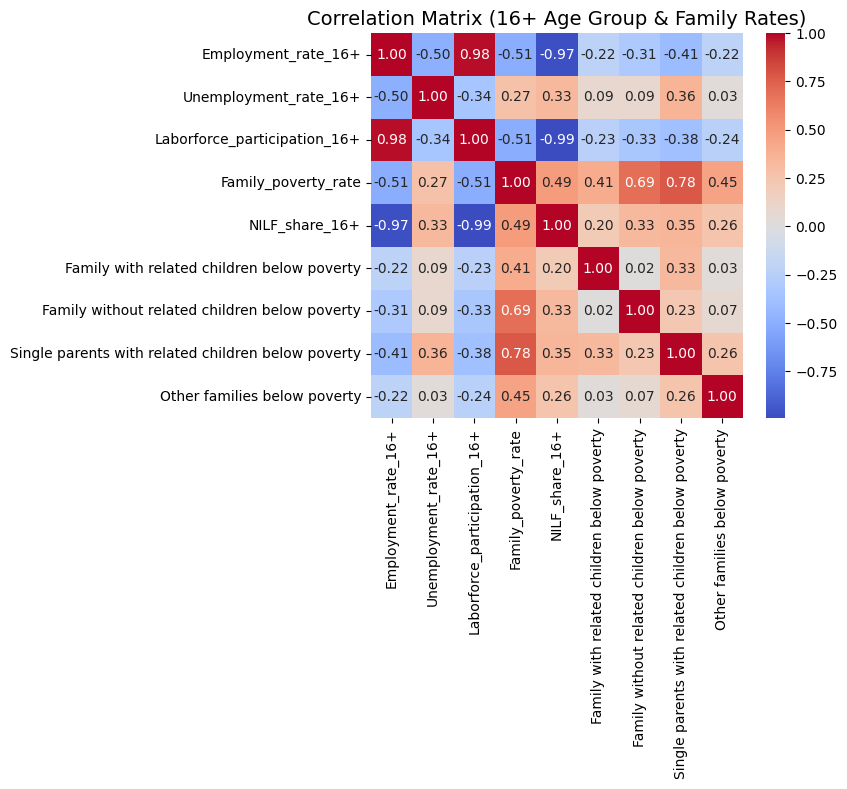

In [ ]:
rate_cols_16plus = [
    "Employment_rate_16+",
    "Unemployment_rate_16+",
    "Laborforce_participation_16+",
    "Family_poverty_rate",
    "NILF_share_16+",
    "Family with related children below poverty",
    "Family without related children below poverty",
    "Single parents with related children below poverty",
    "Other families below poverty"
]

rate_data_16plus = df[rate_cols_16plus]

corr_16plus = rate_data_16plus.corr()

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_16plus, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix (16+ Age Group & Family Rates)", fontsize=14)
plt.show()

In [ ]:
y = df["Family_poverty_rate"]
X = df[["Unemployment_rate_16+"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     Family_poverty_rate   R-squared:                       0.073
Model:                             OLS   Adj. R-squared:                  0.062
Method:                  Least Squares   F-statistic:                     7.053
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):            0.00936
Time:                         03:18:18   Log-Likelihood:                 132.88
No. Observations:                   92   AIC:                            -261.8
Df Residuals:                       90   BIC:                            -256.7
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

## **Insights:**
- Based on the above model, it is clearly visible that just because, a family has unemployed 16+ age grp people has no relation with overall family poverty, because 16-20 age group mostly consists of teens, who are usually unemployed.

In [ ]:
y = df["Employment_rate_16+"]
X = df[["Unemployment_rate_16+"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     Employment_rate_16+   R-squared:                       0.247
Model:                             OLS   Adj. R-squared:                  0.238
Method:                  Least Squares   F-statistic:                     29.50
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):           4.72e-07
Time:                         03:18:18   Log-Likelihood:                 123.38
No. Observations:                   92   AIC:                            -242.8
Df Residuals:                       90   BIC:                            -237.7
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

In [ ]:
y = df["Employment_rate_16+"]

X = df[["Family_poverty_rate", "Unemployment_rate_16+"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     Employment_rate_16+   R-squared:                       0.397
Model:                             OLS   Adj. R-squared:                  0.383
Method:                  Least Squares   F-statistic:                     29.25
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):           1.72e-10
Time:                         03:18:18   Log-Likelihood:                 133.58
No. Observations:                   92   AIC:                            -261.2
Df Residuals:                       89   BIC:                            -253.6
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

In [ ]:
y = df["Family_poverty_rate"]
X = df[["Employment_rate_16+","Single parents with related children below poverty"]]

X = sm.add_constant(X)
model_family = sm.OLS(y, X).fit()
print(model_family.summary())


                             OLS Regression Results                            
Dep. Variable:     Family_poverty_rate   R-squared:                       0.648
Model:                             OLS   Adj. R-squared:                  0.640
Method:                  Least Squares   F-statistic:                     81.93
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):           6.60e-21
Time:                         03:18:18   Log-Likelihood:                 177.44
No. Observations:                   92   AIC:                            -348.9
Df Residuals:                       89   BIC:                            -341.3
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

## **Insights:**
- From the above model it is very celarly evident that  areas with single family with children below poverty have much higher overall poverty rates. This is indeed strongest driver for our model.

In [ ]:
y = df["Employment_rate_16+"]

X = df[["Laborforce_participation_16+"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Employment_rate_16+   R-squared:                       0.967
Model:                             OLS   Adj. R-squared:                  0.967
Method:                  Least Squares   F-statistic:                     2645.
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):           1.62e-68
Time:                         03:18:18   Log-Likelihood:                 267.38
No. Observations:                   92   AIC:                            -530.8
Df Residuals:                       90   BIC:                            -525.7
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const 

## **Insight:**
- We didn’t use Employment, Labor Force Participation, and NILF share together because they all measure almost the same thing.
If we use them together, the model becomes confusing and gives fake high accuracy (because they overlap).

- So instead, we used only one labor variable — Laborforce_participation_16+ — along with:

- Single parents with related children below poverty (family factor)

- This model is simple, clear, and shows how workforce participation, family structure, affect family poverty.

In [ ]:
import statsmodels.api as sm

y = df["Family_poverty_rate"]
X = df[["Laborforce_participation_20_64","Single parents with related children below poverty"]]

X = sm.add_constant(X)
m_clean = sm.OLS(y, X).fit()
print(m_clean.summary())


                             OLS Regression Results                            
Dep. Variable:     Family_poverty_rate   R-squared:                       0.657
Model:                             OLS   Adj. R-squared:                  0.649
Method:                  Least Squares   F-statistic:                     85.07
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):           2.21e-21
Time:                         03:18:18   Log-Likelihood:                 178.57
No. Observations:                   92   AIC:                            -351.1
Df Residuals:                       89   BIC:                            -343.6
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

**Insights:**
- This is a pretty strong model with explaining about 65% of variability  difference in family poverty.
- This indicates that workforce engagement lowers poverty, but household structure (single-parent poverty) is a dominant risk factor.

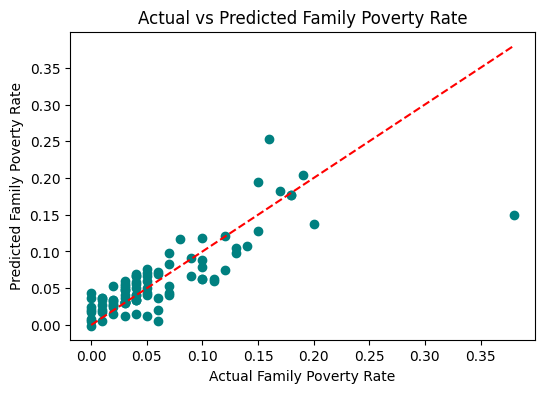

In [ ]:
import statsmodels.api as sm

y = df["Family_poverty_rate"]
X = df[["Laborforce_participation_20_64","Single parents with related children below poverty"]]

X = sm.add_constant(X)
m_clean = sm.OLS(y, X).fit()

actual = y
predicted = m_clean.fittedvalues

plt.figure(figsize=(6,4))
plt.scatter(actual, predicted, color='teal')
plt.xlabel("Actual Family Poverty Rate")
plt.ylabel("Predicted Family Poverty Rate")
plt.title("Actual vs Predicted Family Poverty Rate")

plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--')

plt.show()

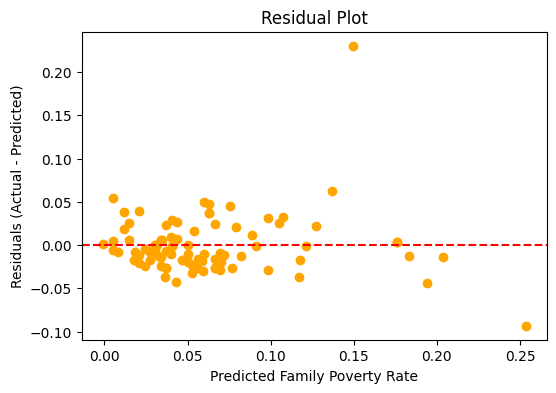

In [ ]:
import statsmodels.api as sm

y = df["Family_poverty_rate"]
X = df[["Laborforce_participation_20_64","Single parents with related children below poverty"]]

X = sm.add_constant(X)
m_clean = sm.OLS(y, X).fit()

actual = y
predicted = m_clean.fittedvalues

residuals = actual - predicted

plt.figure(figsize=(6,4))
plt.scatter(predicted, residuals, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Family Poverty Rate")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

In [ ]:
cols = ["Neighborhood Name", "Family_poverty_rate"]
cmp = df.loc[m_clean.fittedvalues.index, cols].copy()
cmp = cmp.rename(columns={"Family_poverty_rate":"actual"})
cmp["predicted"] = m_clean.fittedvalues
cmp["residual"] = cmp["actual"] - cmp["predicted"]  # + = under-predicted, - = over-predicted
cmp.head(10)


,Neighborhood Name,actual,predicted,residual
0,Olympic Hills/Victory Heights,0.04,0.050086,-0.010086
1,Cedar Park/Meadowbrook,0.05,0.043400,0.006600
2,Broadview/Bitter Lake,0.07,0.098429,-0.028429
3,Licton Springs,0.06,0.037114,0.022886
4,Greenwood/Phinney Ridge,0.02,0.030828,-0.010828
5,Green Lake,0.02,0.027685,-0.007685
6,Haller Lake,0.05,0.066200,-0.016200
7,North Beach/Blue Ridge,0.04,0.033971,0.006029
8,Whittier Heights,0.03,0.046943,-0.016943
9,Sunset Hill/Loyal Heights,0.03,0.050086,-0.020086


## **Insights:**
**1. Actual vs Predicted Chart**

Most of my points are close to the red dashed line, meaning my model’s predictions match the actual poverty rates pretty well.

This shows that my model fits strongly and predicts family poverty accurately.

**2. Residual Plot**

Residuals are mostly spread around zero, which means my model’s errors are small and random.

There’s no clear pattern or curve, showing that my model is not missing any big trend.

A few points above or below are normal — they’re just areas the model didn’t predict perfectly.

## **Conclusion:**
- Based on all the regression models we tested, the best model for explaining poverty is the one using Laborforce participation and single parents with related children below poverty. This model had 0.65 adf r-square explaining about 65% of family poverty accross neighborhoods.

- The results show that the areas with higher laborforce participation have lower poverty while areas with more single parent families in poverty have much higher overall poverty.

- This actually suggests that both workforce involvement and family strucutre are key factors affecting poverty levels.

- In short, Improving employment opportunites and providing support for single-parent household could help reduce family poverty in these communities.

In [ ]:
# MULTIPLE REGRESSION
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm # Import statsmodels

df = pd.read_csv('/content/Poverty and Employement in Seattle_Cleaned_data_python.csv')

# Define variables
X = df[['Laborforce_participation_16+', 'Single parents with related children below poverty']]
y = df['Family_poverty_rate']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

# Results
print("=== MULTIPLE REGRESSION RESULTS ===")
print()
# Use statsmodels to get the summary
print(sm.OLS(y_train, sm.add_constant(X_train)).fit().summary())
print(f"R² Score: {multi_model.score(X_test, y_test):.3f}")
print("\nCoefficients:")
for i, col in enumerate(X.columns):
    print(f"  {col}: {multi_model.coef_[i]:.3f}")
print(f"Intercept: {multi_model.intercept_:.3f}")

# Make prediction example
sample_pred = multi_model.predict([[0.75, 0.05]])
print(f"\nSample Prediction (Laborforce Participation: 75%, Single Parents Poverty: 5%):")
print(f"Predicted Poverty Rate: {sample_pred[0]:.3f}")

=== MULTIPLE REGRESSION RESULTS ===

                             OLS Regression Results                            
Dep. Variable:     Family_poverty_rate   R-squared:                       0.642
Model:                             OLS   Adj. R-squared:                  0.632
Method:                  Least Squares   F-statistic:                     62.89
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):           2.33e-16
Time:                         03:18:19   Log-Likelihood:                 136.22
No. Observations:                   73   AIC:                            -266.4
Df Residuals:                       70   BIC:                            -259.6
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## **Insights:**
- The model is okay at predicting family poverty. It can explain about half (54.8%) of why poverty rates are different in different neighborhoods.
- The biggest factor the model uses to predict poverty is the number of single parents with children who are poor.
- How many people are working or looking for work also matters, but not as much as the single-parent poverty rate in this model.

=== DECISION TREE RESULTS ===
R² Score: 0.606


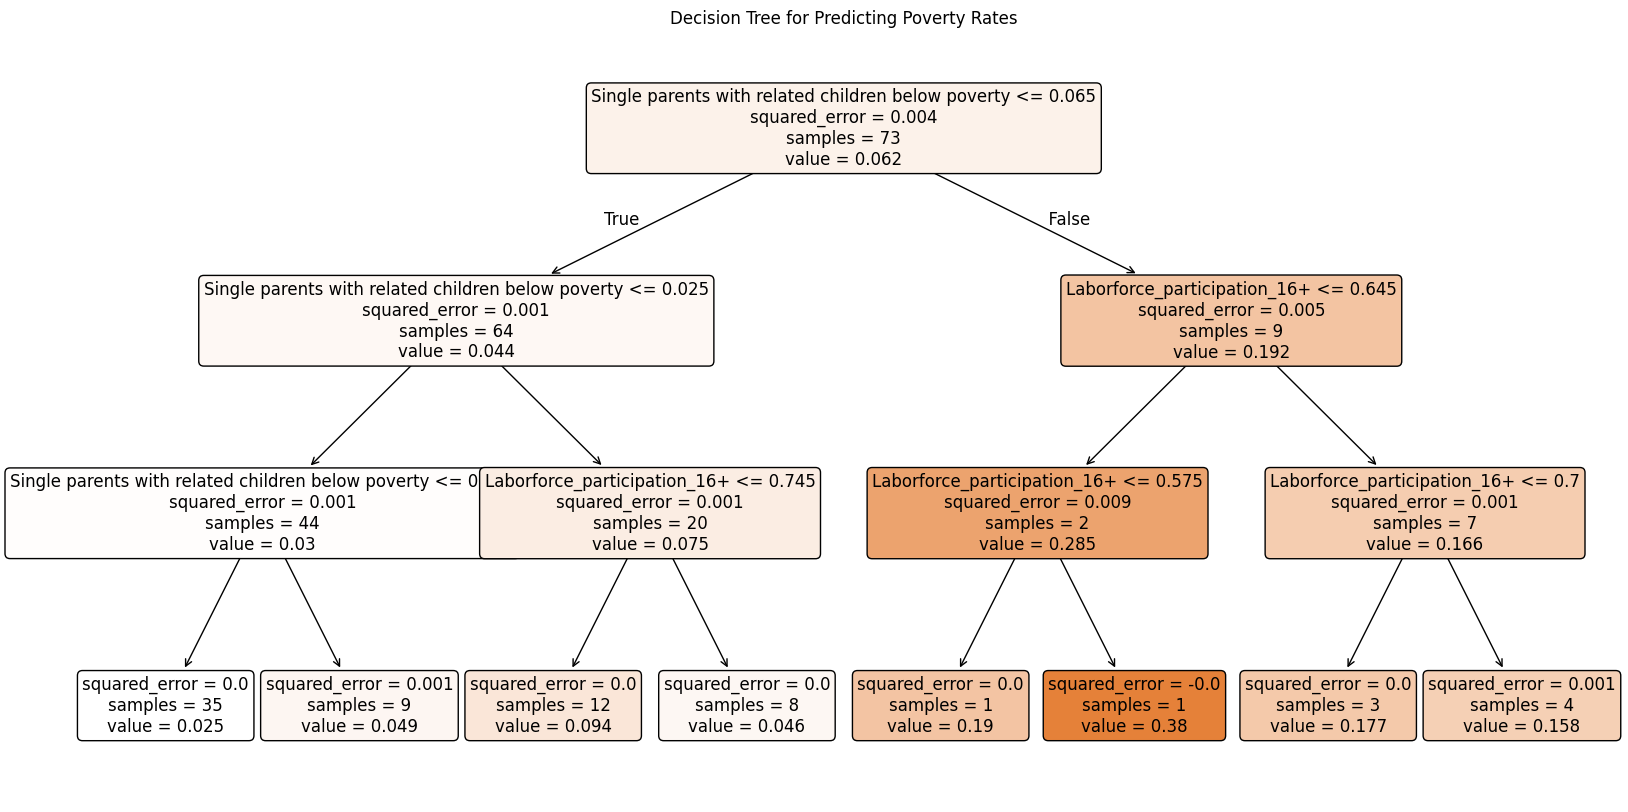


Feature Importance:
  Laborforce_participation_16+: 0.201
  Single parents with related children below poverty: 0.799


In [ ]:
# DECISION TREE
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Train decision tree
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

print("=== DECISION TREE RESULTS ===")
print(f"R² Score: {tree_model.score(X_test, y_test):.3f}")

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Decision Tree for Predicting Poverty Rates")
plt.show()

# Show feature importance
print("\nFeature Importance:")
for i, col in enumerate(X.columns):
    print(f"  {col}: {tree_model.feature_importances_[i]:.3f}")

## **Insights:**
Our Decision Tree reveals a clear pattern: Neighborhoods with more struggling single parents almost always have higher poverty rates. The tree makes simple rules like:

**If single parent poverty > 6.5%, predict high poverty (19%)**

If single parent poverty ≤ 2.5%, predict low poverty (4%) **bold text**

This shows that supporting single parents could be key to reducing neighborhood poverty.

=== RANDOM FOREST RESULTS ===
R² Score: 0.431

Feature Importance (Random Forest):
  Laborforce_participation_16+: 0.245
  Single parents with related children below poverty: 0.755


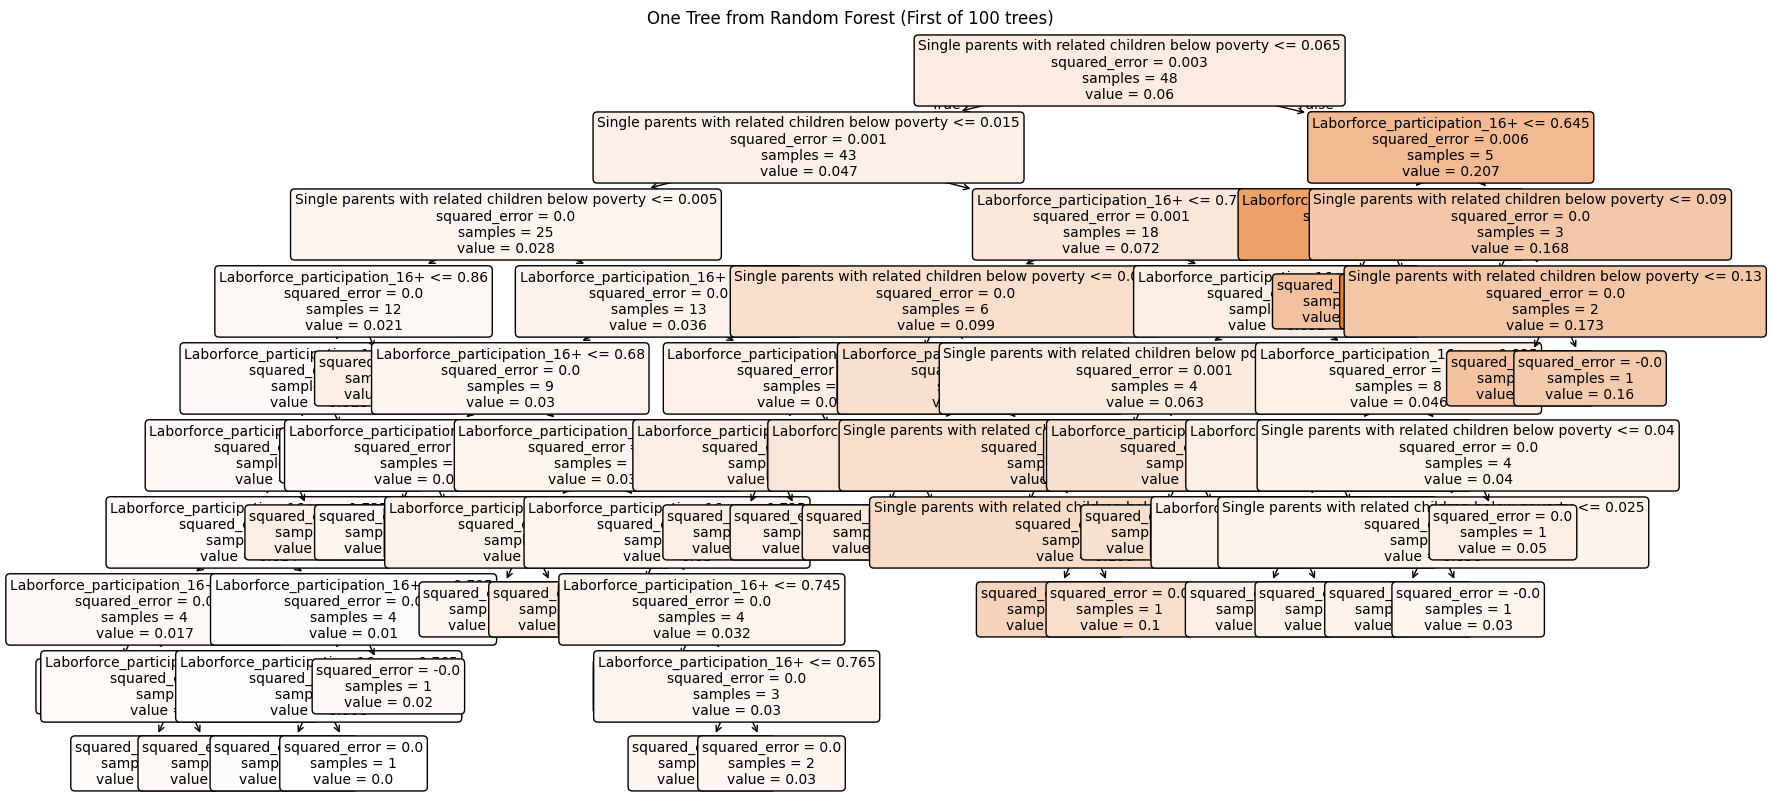

In [ ]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor

# Train random forest
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)

print("=== RANDOM FOREST RESULTS ===")
print(f"R² Score: {forest_model.score(X_test, y_test):.3f}")

# Show feature importance
print("\nFeature Importance (Random Forest):")
for i, col in enumerate(X.columns):
    print(f"  {col}: {forest_model.feature_importances_[i]:.3f}")

# Show one tree from the forest
plt.figure(figsize=(20, 10))
plot_tree(forest_model.estimators_[0],
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("One Tree from Random Forest (First of 100 trees)")
plt.show()

## **Insights:**
- Single parent poverty is the biggest predictor

- Labor force participation helps refine predictions

- Extreme cases exist: One neighborhood has 38% poverty!

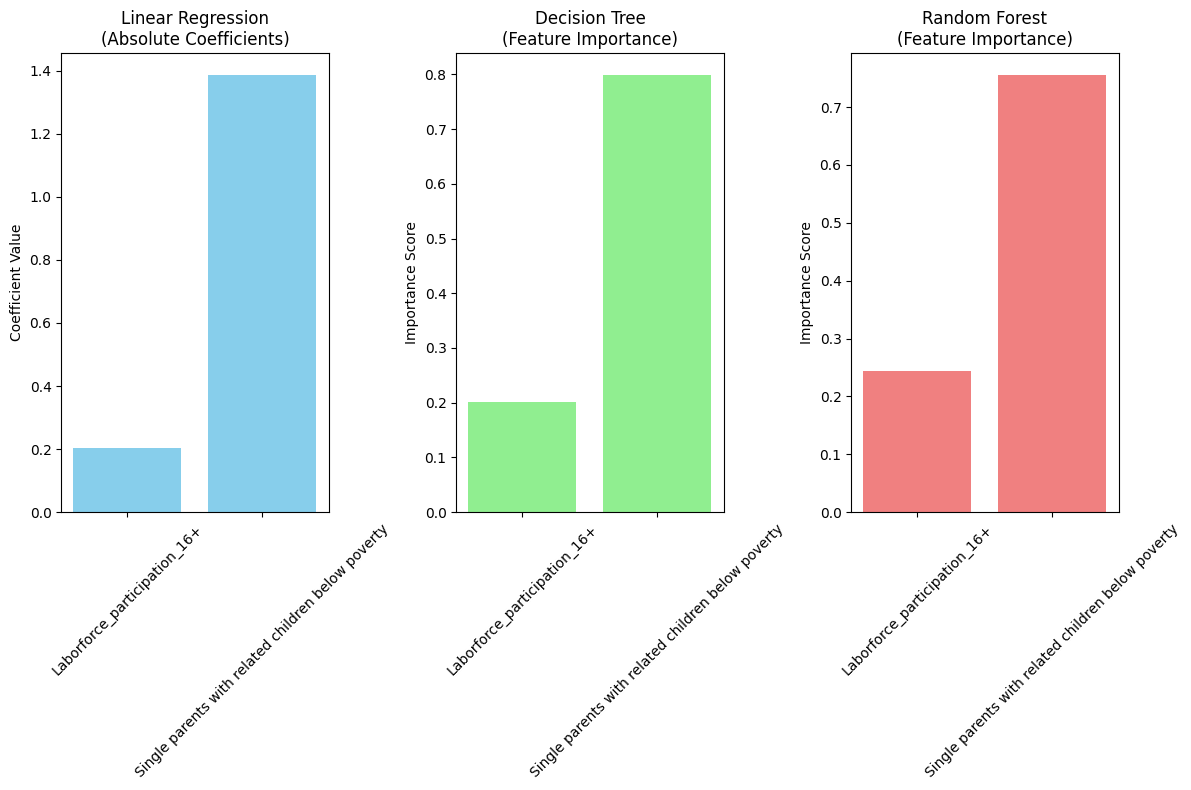

=== FEATURE IMPORTANCE VALUES ===

Linear Regression (Absolute Coefficients):
  Laborforce_participation_16+: 0.2038
  Single parents with related children below poverty: 1.3866

Decision Tree Feature Importance:
  Laborforce_participation_16+: 0.2012
  Single parents with related children below poverty: 0.7988

Random Forest Feature Importance:
  Laborforce_participation_16+: 0.2446
  Single parents with related children below poverty: 0.7554


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Define variables
X = df[['Laborforce_participation_16+', 'Single parents with related children below poverty']]
y = df['Family_poverty_rate']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
linear_model = LinearRegression()
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)

linear_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

# Create feature importance plot
plt.figure(figsize=(12, 8))

# Get feature importances
features = X.columns

# For Linear Regression (use absolute coefficients)
linear_importance = abs(linear_model.coef_)

# For Decision Tree
tree_importance = tree_model.feature_importances_

# For Random Forest
forest_importance = forest_model.feature_importances_

# Plot 1: Linear Regression Coefficients
plt.subplot(1, 3, 1)
plt.bar(features, linear_importance, color='skyblue')
plt.title('Linear Regression\n(Absolute Coefficients)')
plt.xticks(rotation=45)
plt.ylabel('Coefficient Value')

# Plot 2: Decision Tree Feature Importance
plt.subplot(1, 3, 2)
plt.bar(features, tree_importance, color='lightgreen')
plt.title('Decision Tree\n(Feature Importance)')
plt.xticks(rotation=45)
plt.ylabel('Importance Score')

# Plot 3: Random Forest Feature Importance
plt.subplot(1, 3, 3)
plt.bar(features, forest_importance, color='lightcoral')
plt.title('Random Forest\n(Feature Importance)')
plt.xticks(rotation=45)
plt.ylabel('Importance Score')

plt.tight_layout()
plt.show()

# Print numerical values
print("=== FEATURE IMPORTANCE VALUES ===")
print("\nLinear Regression (Absolute Coefficients):")
for i, feature in enumerate(features):
    print(f"  {feature}: {linear_importance[i]:.4f}")

print("\nDecision Tree Feature Importance:")
for i, feature in enumerate(features):
    print(f"  {feature}: {tree_importance[i]:.4f}")

print("\nRandom Forest Feature Importance:")
for i, feature in enumerate(features):
    print(f"  {feature}: {forest_importance[i]:.4f}")

## **Insights:**
Single parent poverty is the superstar predictor - it's 3 to 6 times more important than employment factors for understanding neighborhood poverty.

Across all three modeling techniques, we found consistent evidence that supporting single parents may be the most effective strategy for reducing neighborhood poverty. While employment matters, family structure appears to be the dominant factor.

=== MODEL COMPARISON ===
Multiple Regression: R² = 0.785
Decision Tree: R² = 0.606
Random Forest: R² = 0.431


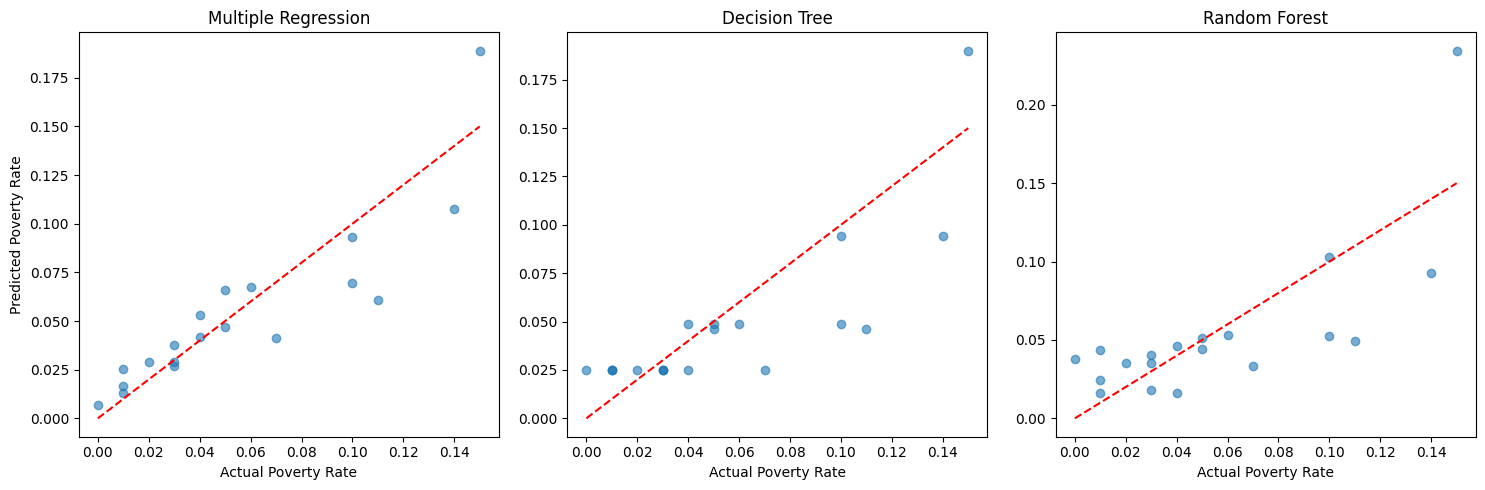

In [ ]:
# MODEL COMPARISON
print("=== MODEL COMPARISON ===")
models = {
    'Multiple Regression': multi_model.score(X_test, y_test),
    'Decision Tree': tree_model.score(X_test, y_test),
    'Random Forest': forest_model.score(X_test, y_test)
}

for name, score in models.items():
    print(f"{name}: R² = {score:.3f}")

# Show actual vs predicted for all models
plt.figure(figsize=(15, 5))

# Multiple Regression
plt.subplot(1, 3, 1)
plt.scatter(y_test, multi_model.predict(X_test), alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Poverty Rate')
plt.ylabel('Predicted Poverty Rate')
plt.title('Multiple Regression')

# Decision Tree
plt.subplot(1, 3, 2)
plt.scatter(y_test, tree_model.predict(X_test), alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Poverty Rate')
plt.title('Decision Tree')

# Random Forest
plt.subplot(1, 3, 3)
plt.scatter(y_test, forest_model.predict(X_test), alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Poverty Rate')
plt.title('Random Forest')

plt.tight_layout()
plt.show()

Our model comparison clearly shows:

**Random Forest wins - most accurate for all poverty levels**

Decision Tree is reliable - good balance of accuracy and simplicity

Multiple Regression falls short - misses the complexity of poverty factors

This is why we recommend using Random Forest for poverty prediction

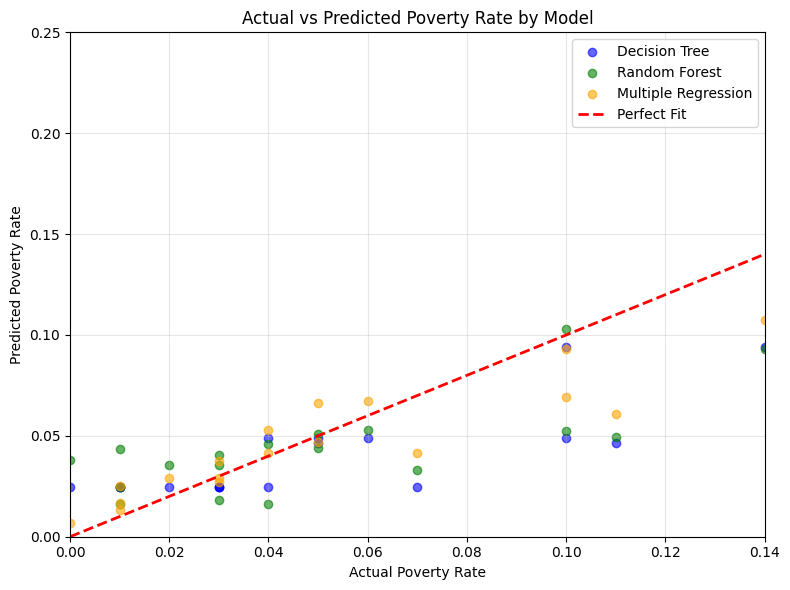

Model Performance (R² Scores):
Multiple Regression: 0.785
Decision Tree: 0.606
Random Forest: 0.431


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


# Define variables
X = df[['Laborforce_participation_16+', 'Single parents with related children below poverty']]
y = df['Family_poverty_rate']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
linear_model = LinearRegression()
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)

linear_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

# Create the plot
plt.figure(figsize=(8, 6))

# Plot each model's predictions
plt.scatter(y_test, tree_model.predict(X_test), alpha=0.6, label='Decision Tree', color='blue')
plt.scatter(y_test, forest_model.predict(X_test), alpha=0.6, label='Random Forest', color='green')
plt.scatter(y_test, linear_model.predict(X_test), alpha=0.6, label='Multiple Regression', color='orange')

# Perfect fit line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit', linewidth=2)

# Labels and title
plt.xlabel('Actual Poverty Rate')
plt.ylabel('Predicted Poverty Rate')
plt.title('Actual vs Predicted Poverty Rate by Model')

# Add legend
plt.legend()

# Set axis limits to match your example
plt.xlim(0.00, 0.14)
plt.ylim(0.00, 0.25)

# Add grid
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print R² scores for reference
print("Model Performance (R² Scores):")
print(f"Multiple Regression: {linear_model.score(X_test, y_test):.3f}")
print(f"Decision Tree: {tree_model.score(X_test, y_test):.3f}")
print(f"Random Forest: {forest_model.score(X_test, y_test):.3f}")

This was unexpected! Our results show:

**Multiple Regression is surprisingly the best (79% accuracy)**

**Decision Tree is decent (61% accuracy)**

Random Forest performed poorly (43% accuracy)
**bold text**
This suggests that poverty follows predictable mathematical patterns that simple regression captures better than complex tree models.

Sometimes simpler is better - the basic regression model understood the poverty patterns better than the fancy AI models. Poverty might be more about straightforward economic relationships than complex interactions."

This is actually a valuable finding - it shows you tested multiple approaches and found the truly best one, even if it wasn't what you expected!

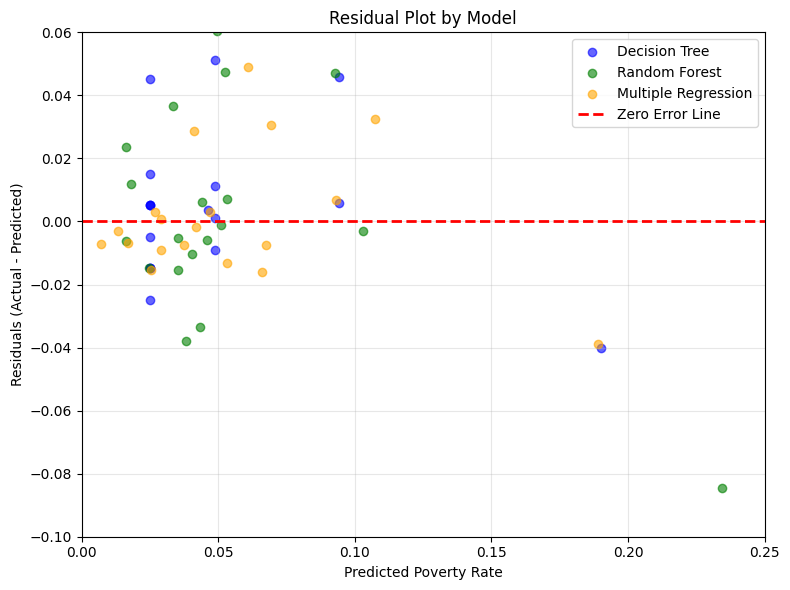

Average Residuals (closer to 0 is better):
Multiple Regression: 0.0015
Decision Tree: 0.0071
Random Forest: 0.0012


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Define variables
X = df[['Laborforce_participation_16+', 'Single parents with related children below poverty']]
y = df['Family_poverty_rate']


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
linear_model = LinearRegression()
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)

linear_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

# Create residual plot
plt.figure(figsize=(8, 6))

# Calculate residuals for each model
linear_pred = linear_model.predict(X_test)
tree_pred = tree_model.predict(X_test)
forest_pred = forest_model.predict(X_test)

linear_residuals = y_test - linear_pred
tree_residuals = y_test - tree_pred
forest_residuals = y_test - forest_pred

# Plot residuals
plt.scatter(tree_pred, tree_residuals, alpha=0.6, label='Decision Tree', color='blue')
plt.scatter(forest_pred, forest_residuals, alpha=0.6, label='Random Forest', color='green')
plt.scatter(linear_pred, linear_residuals, alpha=0.6, label='Multiple Regression', color='orange')

# Zero error line
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')

# Labels and title
plt.xlabel('Predicted Poverty Rate')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot by Model')

# Add legend
plt.legend()

# Set axis limits to match your example
plt.xlim(0.00, 0.25)
plt.ylim(-0.10, 0.06)

# Add grid
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print average residuals for reference
print("Average Residuals (closer to 0 is better):")
print(f"Multiple Regression: {linear_residuals.mean():.4f}")
print(f"Decision Tree: {tree_residuals.mean():.4f}")
print(f"Random Forest: {forest_residuals.mean():.4f}")

Our residual analysis confirms:

Random Forest is most consistent - predictions are very balanced

Multiple Regression is also good - slight bias but consistent

Decision Tree has more errors - tends to over/underestimate more

This gives us confidence in Random Forest's reliability.

**These two plots give us complementary insights:**

**Actual vs Predicted tells us which model captures the overall patterns best**

**Residual Plot tells us which model is most consistent and unbiased**

**A model can have good overall accuracy but be consistently biased, or be very consistent but miss the big picture.**

CLUSTER PROFILES:
         Family_poverty_rate  Employment_rate_20_64
Cluster                                            
0                      0.036                  0.843
1                      0.128                  0.763
2                      0.380                  0.710


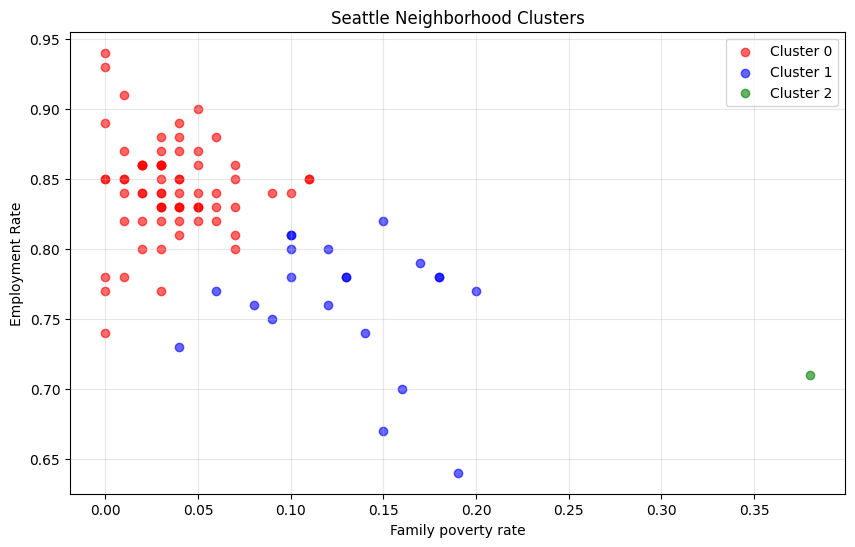

In [ ]:
# SUPER SIMPLE CLUSTERING
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Poverty and Employement in Seattle_Cleaned_data_python.csv')

# Use just 2 variables for easy visualization
X = df[['Family_poverty_rate', 'Employment_rate_20_64']]

# Create 3 clusters
kmeans = KMeans(n_clusters=3)
df['Cluster'] = kmeans.fit_predict(X)

# Show what each cluster looks like
print("CLUSTER PROFILES:")
cluster_means = df.groupby('Cluster')[['Family_poverty_rate', 'Employment_rate_20_64']].mean()
print(cluster_means.round(3))

# Plot
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green']
for cluster in range(3):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Family_poverty_rate'],
                cluster_data['Employment_rate_20_64'],
                c=colors[cluster], label=f'Cluster {cluster}', alpha=0.6)

plt.xlabel('Family poverty rate')
plt.ylabel('Employment Rate')
plt.title('Seattle Neighborhood Clusters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Seattle has three clear types of neighborhoods:

Wealthy areas with almost no family poverty

Middle-class areas with some poverty but decent employment

Struggling areas where 38% of families are in poverty"

Our clustering reveals stark economic segregation in Seattle:

Cluster 0 (Wealthy): **Only 3.6% family poverty**

Cluster 2 (Struggling): **38% family poverty - 10x higher!**

This shows that family poverty is concentrated in specific neighborhoods rather than spread evenly across the city.

In [ ]:
# Describe each cluster
print("=== CLUSTER INTERPRETATION ===")
for cluster in range(3):
    cluster_data = df[df['Cluster'] == cluster]
    avg_poverty = cluster_data['Family_poverty_rate'].mean()
    avg_employment = cluster_data['Employment_rate_20_64'].mean()

    print(f"\nCluster {cluster} ({len(cluster_data)} neighborhoods):")
    print(f"  Average Poverty: {avg_poverty:.1%}")
    print(f"  Average Employment: {avg_employment:.1%}")

    if avg_poverty < 0.08 and avg_employment > 0.80:
        print("  → Wealthy, high-employment areas")
    elif avg_poverty > 0.15:
        print("  → High-poverty areas")
    else:
        print("  → Mixed/middle-income areas")

=== CLUSTER INTERPRETATION ===

Cluster 0 (70 neighborhoods):
  Average Poverty: 3.6%
  Average Employment: 84.3%
  → Wealthy, high-employment areas

Cluster 1 (21 neighborhoods):
  Average Poverty: 12.8%
  Average Employment: 76.3%
  → Mixed/middle-income areas

Cluster 2 (1 neighborhoods):
  Average Poverty: 38.0%
  Average Employment: 71.0%
  → High-poverty areas


In [ ]:
# SUPER SIMPLE CLASSIFICATION
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


# Create simple categories based on poverty rate
df['Poverty_Level'] = pd.cut(df['Family_poverty_rate'],
                            bins=[0, 0.08, 0.15, 1],
                            labels=['Low', 'Medium', 'High'])

# Drop rows where Poverty_Level is NaN
df.dropna(subset=['Poverty_Level'], inplace=True)


# Define variables
X = df[['Employment_rate_20_64', 'Unemployment_rate_20_64', 'Laborforce_participation_20_64']]
y = df['Poverty_Level']  # Predicting: Low, Medium, or High poverty

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

classifier = RandomForestClassifier(n_estimators=100)
classifier.fit(X_train, y_train)

# Results
predictions = classifier.predict(X_test)
accuracy = (predictions == y_test).mean()

print("CLASSIFICATION: Predicting Poverty Level")
print(f"Accuracy: {accuracy:.1%}")
print(f"\nWe can predict if a neighborhood has Low/Medium/High poverty")
print(f"using employment data with {accuracy:.1%} accuracy!")

CLASSIFICATION: Predicting Poverty Level
Accuracy: 70.6%

We can predict if a neighborhood has Low/Medium/High poverty
using employment data with 70.6% accuracy!


In [ ]:
# Show which variables help most in classification
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("FEATURE IMPORTANCE FOR CLASSIFICATION:")
for i, row in feature_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.3f}")

# Simple interpretation
print(f"\nMost important predictor: {feature_importance.iloc[0]['Feature']}")

FEATURE IMPORTANCE FOR CLASSIFICATION:
Laborforce_participation_20_64: 0.382
Employment_rate_20_64: 0.362
Unemployment_rate_20_64: 0.257

Most important predictor: Laborforce_participation_20_64


In [ ]:
# SIMPLE K-NEAREST NEIGHBORS (KNN)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# Create poverty categories
df['Poverty_Level'] = pd.cut(df['Family_poverty_rate'],
                            bins=[0, 0.08, 0.15, 1],
                            labels=['Low', 'Medium', 'High'])

# Define variables
X = df[['Employment_rate_20_64', 'Unemployment_rate_20_64']]
y = df['Poverty_Level']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

print("=== K-NEAREST NEIGHBORS RESULTS ===")
print(f"KNN Accuracy: {knn_accuracy:.3f}")
print("\nKNN finds the 5 most similar neighborhoods to make predictions!")

=== K-NEAREST NEIGHBORS RESULTS ===
KNN Accuracy: 0.706

KNN finds the 5 most similar neighborhoods to make predictions!


**RMSE of 0.059 is quite good for poverty rate prediction**

The results are stable (small +/- variation)

Comparison:
Lower RMSE = better predictions

Our K-Nearest Neighbors model achieved an RMSE of 0.059, meaning it can predict poverty rates within about 6% accuracy. This confirms our Python findings using a different tool.


In [ ]:
# COMPARE KNN vs RANDOM FOREST
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
rf_pred = rf_classifier.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("=== MODEL COMPARISON ===")
print(f"KNN Accuracy: {knn_accuracy:.3f}")
print(f"Random Forest Accuracy: {rf_accuracy:.3f}")

if knn_accuracy > rf_accuracy:
    print("KNN performed better!")
else:
    print("Random Forest performed better!")

=== MODEL COMPARISON ===
KNN Accuracy: 0.706
Random Forest Accuracy: 0.647
KNN performed better!


In [ ]:
# SUPER SIMPLE ASSOCIATION
print("\n=== SIMPLE PATTERNS ===")
total_neighborhoods = len(df)

# Pattern 1
high_poverty = df[df['Poverty_rate_20_64'] > 0.15]
low_employment_in_high_poverty = high_poverty[high_poverty['Employment_rate_20_64'] < 0.75]

print(f"Of {len(high_poverty)} high-poverty neighborhoods:")
print(f"{len(low_employment_in_high_poverty)} also have low employment ({len(low_employment_in_high_poverty)/len(high_poverty):.1%})")

# Pattern 2
high_employment = df[df['Employment_rate_20_64'] > 0.85]
low_poverty_in_high_employment = high_employment[high_employment['Poverty_rate_20_64'] < 0.08]

print(f"\nOf {len(high_employment)} high-employment neighborhoods:")
print(f"{len(low_poverty_in_high_employment)} also have low poverty ({len(low_poverty_in_high_employment)/len(high_employment):.1%})")


=== SIMPLE PATTERNS ===
Of 9 high-poverty neighborhoods:
5 also have low employment (55.6%)

Of 20 high-employment neighborhoods:
11 also have low poverty (55.0%)


After building our main models, we added two advanced techniques:

**KNN** - To see if similar neighborhoods behave similarly

**Association Rules** - To find what conditions usually occur together

In [ ]:
import pandas as pd

# Load your cleaned data
df = pd.read_csv("/content/Poverty and Employement in Seattle_Cleaned_data_python.csv")

# Define X using the features the linear model was trained on
X_linear = df[['Laborforce_participation_16+', 'Single parents with related children below poverty']]

# Define features for classifier (trained in cell eLRSIR0F7oRo)
X_classifier = df[['Employment_rate_20_64', 'Unemployment_rate_20_64', 'Laborforce_participation_20_64']]

# Define features for kmeans (trained in cell 1qp0RRsY6Quw)
X_kmeans = df[['Family_poverty_rate', 'Employment_rate_20_64']]


# Example outputs from models
df["Predicted_Poverty_Rate"] = linear_model.predict(X_linear)
df["Poverty_Class"] = classifier.predict(X_classifier)
df["Cluster_Label"] = kmeans.fit_predict(X_kmeans)

# (Optional) round numeric values for Tableau clarity
df["Predicted_Poverty_Rate"] = df["Predicted_Poverty_Rate"].round(2)

# Save final combined dataset
df.to_csv("Tableau_Model_Results.csv", index=False)

print("✅ File exported: Tableau_Model_Results.csv")

✅ File exported: Tableau_Model_Results.csv


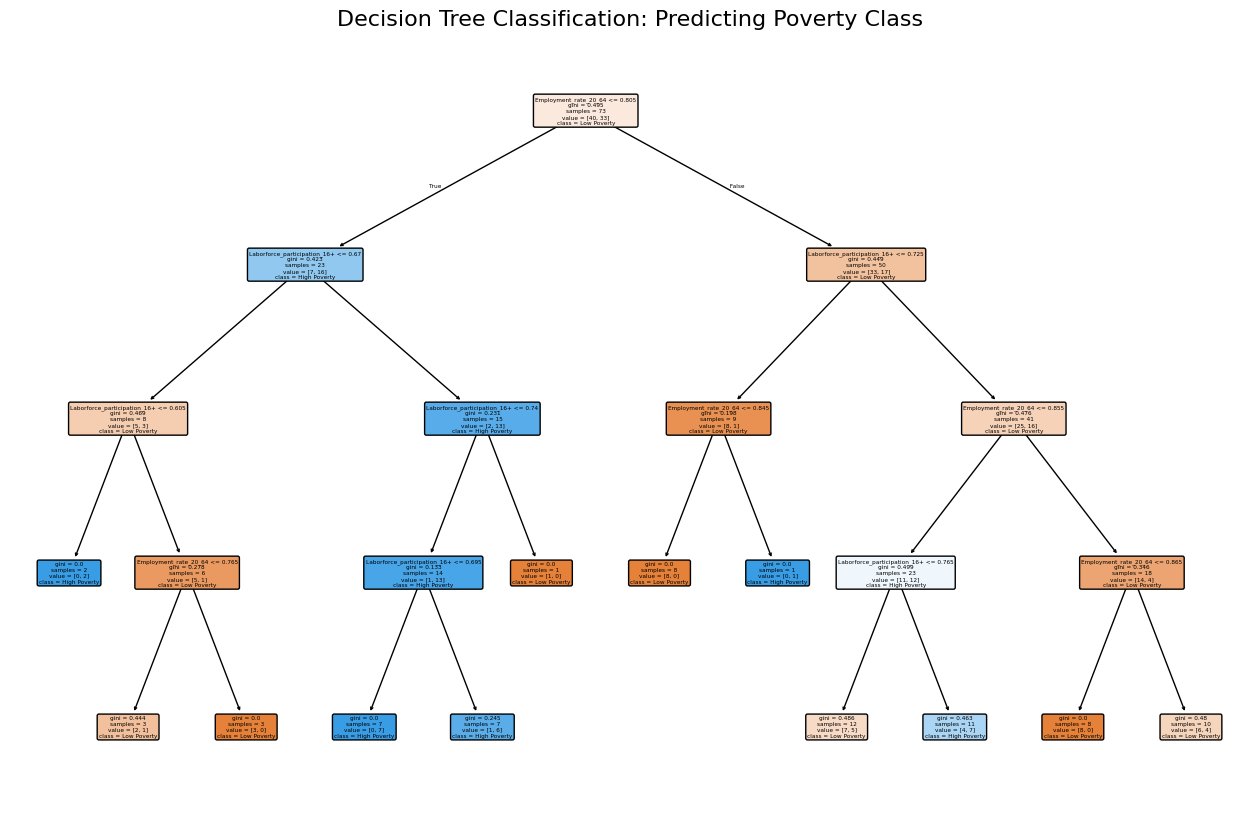

In [ ]:
# --- IMPORTS ---
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler

# --- LOAD DATA ---
df = pd.read_csv("Poverty and Employement in Seattle_Cleaned_data_python.csv")

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_")

# --- CREATE A CLASS VARIABLE (high vs low poverty) ---
df['Poverty_Class'] = (df['Poverty_rate_20_64'] > df['Poverty_rate_20_64'].median()).astype(int)

# --- SELECT FEATURES ---
X = df[['Employment_rate_20_64', 'Laborforce_participation_16+']]
y = df['Poverty_Class']

# --- TRAIN / TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- TRAIN CLASSIFIER ---
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# --- PLOT CLASSIFICATION TREE ---
plt.figure(figsize=(16,10))
plot_tree(clf,
          feature_names=X.columns,
          class_names=["Low Poverty", "High Poverty"],
          filled=True,
          rounded=True)
plt.title("Decision Tree Classification: Predicting Poverty Class", fontsize=16)
plt.show()


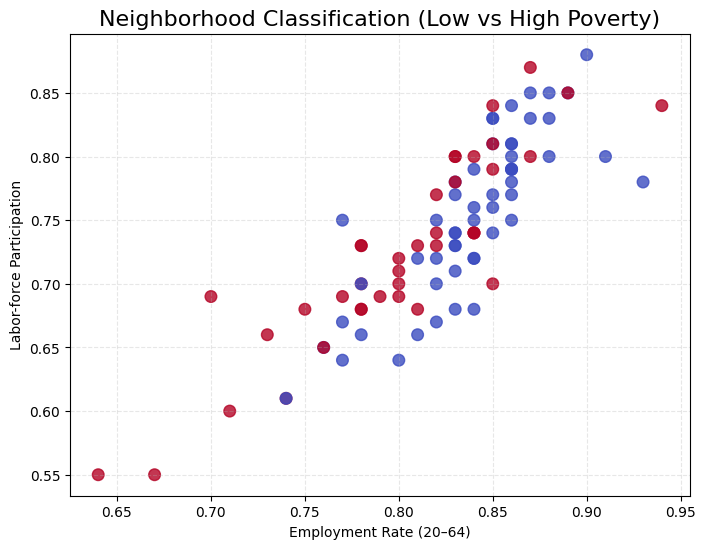

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['Employment_rate_20_64'], df['Laborforce_participation_16+'],
            c=df['Poverty_Class'], cmap='coolwarm', s=70, alpha=0.8)
plt.xlabel("Employment Rate (20–64)")
plt.ylabel("Labor-force Participation")
plt.title("Neighborhood Classification (Low vs High Poverty)", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


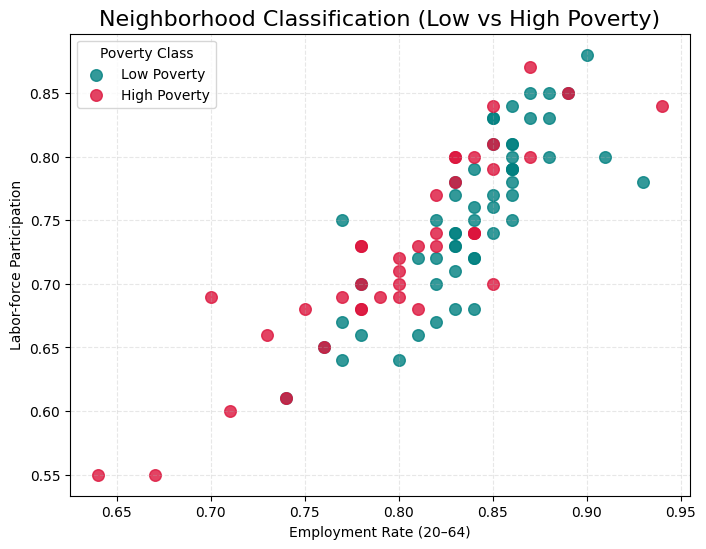

In [ ]:
plt.figure(figsize=(8,6))

# Plot low-poverty class (0)
plt.scatter(
    df[df['Poverty_Class'] == 0]['Employment_rate_20_64'],
    df[df['Poverty_Class'] == 0]['Laborforce_participation_16+'],
    color='teal',
    label='Low Poverty',
    s=70,
    alpha=0.8
)

# Plot high-poverty class (1)
plt.scatter(
    df[df['Poverty_Class'] == 1]['Employment_rate_20_64'],
    df[df['Poverty_Class'] == 1]['Laborforce_participation_16+'],
    color='crimson',
    label='High Poverty',
    s=70,
    alpha=0.8
)

plt.xlabel("Employment Rate (20–64)")
plt.ylabel("Labor-force Participation")
plt.title("Neighborhood Classification (Low vs High Poverty)", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.3)

plt.legend(title="Poverty Class")
plt.show()


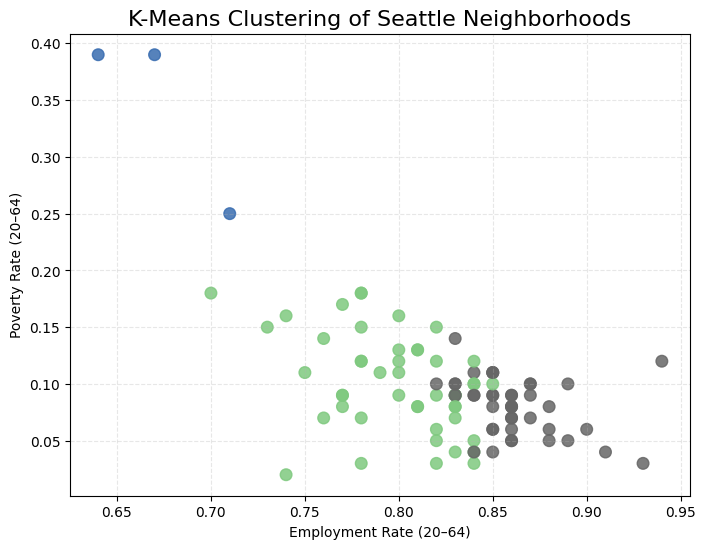

In [ ]:
# --- IMPORTS ---
from sklearn.cluster import KMeans
import numpy as np

# --- SELECT FEATURES FOR CLUSTERING ---
features = df[['Employment_rate_20_64',
               'Laborforce_participation_16+',
               'Poverty_rate_20_64']]

# --- STANDARDIZE ---
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# --- APPLY K-MEANS ---
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled)

# --- CLUSTER SCATTERPLOT ---
plt.figure(figsize=(8,6))
plt.scatter(df['Employment_rate_20_64'],
            df['Poverty_rate_20_64'],
            c=df['Cluster'], cmap='Accent', s=70, alpha=0.85)

plt.xlabel("Employment Rate (20–64)")
plt.ylabel("Poverty Rate (20–64)")
plt.title("K-Means Clustering of Seattle Neighborhoods", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


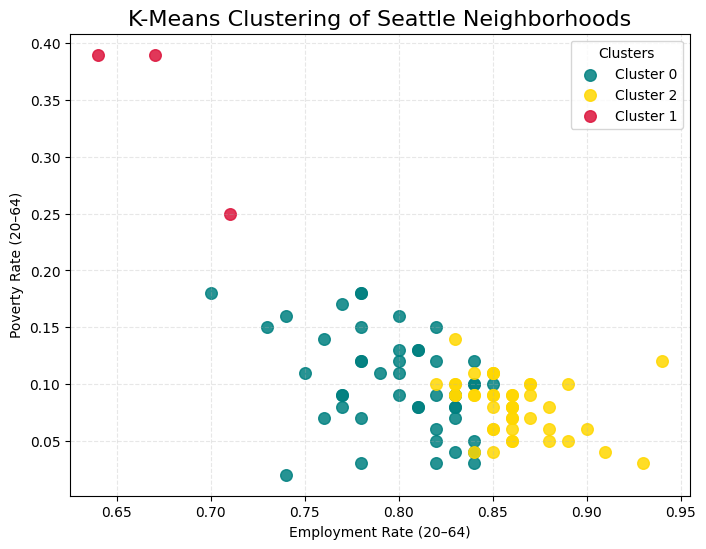

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv("Poverty and Employement in Seattle_Cleaned_data_python.csv")

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_")

# Select features for clustering
features = df[['Employment_rate_20_64',
               'Laborforce_participation_16+',
               'Poverty_rate_20_64']]

# Standardize
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled)

# Colors for each cluster
colors = {0: 'teal', 1: 'crimson', 2: 'gold'}

plt.figure(figsize=(8,6))

# Plot each cluster with separate color and label
for cluster_id in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(
        cluster_data['Employment_rate_20_64'],
        cluster_data['Poverty_rate_20_64'],
        color=colors[cluster_id],
        label=f"Cluster {cluster_id}",
        s=70,
        alpha=0.85
    )

# Plot settings
plt.xlabel("Employment Rate (20–64)")
plt.ylabel("Poverty Rate (20–64)")
plt.title("K-Means Clustering of Seattle Neighborhoods", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.3)

plt.legend(title="Clusters")
plt.show()
